In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten
from keras.utils import to_categorical
import cv2
import numpy as np
from keras.utils import load_img, img_to_array
import matplotlib.pyplot as plt
from google.colab import drive
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os

In [ ]:
drive.mount('/content/drive')
file_path = "/content/drive/MyDrive/DA/flower_photos"

Mounted at /content/drive


In [ ]:
train_datagen = ImageDataGenerator(rescale = 1./255,
                                   rotation_range = 30,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   fill_mode = 'nearest')

In [ ]:
train_generator = train_datagen.flow_from_directory(
    file_path,
    target_size = (64, 64), # Tăng lên 64 để nét hơn
    batch_size = 32,
    class_mode = 'categorical'
)

Found 3670 images belonging to 5 classes.


In [ ]:
import os

# List contents of the directory specified by file_path
print(f"Contents of '{file_path}':")
for item in os.listdir(file_path):
    print(f"- {item}")

# Optionally, you can also list the class names that ImageDataGenerator found
print("\nClass names found by ImageDataGenerator:")
print(train_generator.class_indices)

Contents of '/content/drive/MyDrive/DA/flower_photos':
- LICENSE.txt
- sunflowers
- tulips
- dandelion
- roses
- daisy

Class names found by ImageDataGenerator:
{'daisy': 0, 'dandelion': 1, 'roses': 2, 'sunflowers': 3, 'tulips': 4}


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

model = Sequential([
    Input(shape=(64, 64, 3)), # Khai báo đầu vào chuẩn xác

    # Khối CNN 1
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Khối CNN 2
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Khối CNN 3
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    # Chuyển sang lớp phân loại
    Flatten(),
    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3), # Giảm xuống 0.3 để học tốt hơn trong 50 epochs
    Dense(5, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,861 (8.37 MB)

 Trainable params: 2,192,901 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Huấn luyện
history = model.fit(train_generator, epochs=50)

Epoch 1/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 829s 7s/step - accuracy: 0.4856 - loss: 1.4738
Epoch 2/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 72s 622ms/step - accuracy: 0.5763 - loss: 1.1332
Epoch 3/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 610ms/step - accuracy: 0.6104 - loss: 1.0205
Epoch 4/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 610ms/step - accuracy: 0.6308 - loss: 0.9525
Epoch 5/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 69s 596ms/step - accuracy: 0.6624 - loss: 0.8939
Epoch 6/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 69s 599ms/step - accuracy: 0.6706 - loss: 0.8361
Epoch 7/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 74s 636ms/step - accuracy: 0.6896 - loss: 0.8033
Epoch 8/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 606ms/step - accuracy: 0.6951 - loss: 0.7821
Epoch 9/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 73s 633ms/step - accuracy: 0.7150 - loss: 0.7499
Epoch 10/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 69s 600ms/step - accuracy: 0.7234 - loss: 0.7247
Epoch 11/50
115/115 ━━━━━━━━━━━━━━━━━━━━ 70s 607ms/step - accuracy: 0.7324 - loss: 0.7089
Epoch 12/50
115/115 ━

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
model.save("nhandienhoa.h5")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('nhandienhoa.h5')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,193,863 (8.37 MB)

 Trainable params: 2,192,901 (8.37 MB)

 Non-trainable params: 960 (3.75 KB)

 Optimizer params: 2 (12.00 B)

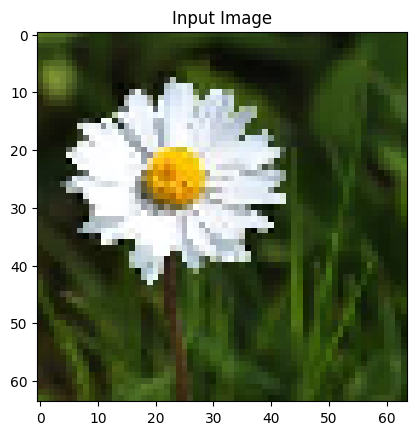

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicted class: daisy


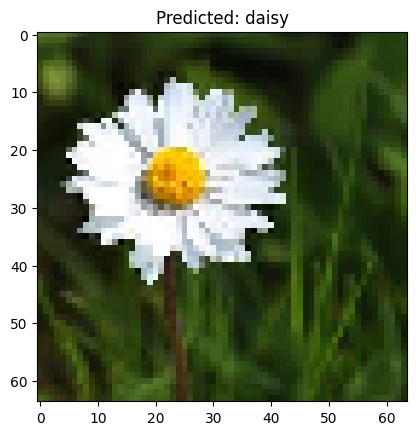

In [ ]:
path = "/content/drive/MyDrive/DA/Hoa/daisy test.jpg"
img_display = load_img(path, target_size=(64, 64))
plt.imshow(img_display)
plt.title("Input Image")
plt.show()

img = np.array(img_display)
img = img/255.0
img = img.reshape(1,64,64,3)

prediction = np.argmax(model.predict(img))
class_labels = {v: k for k, v in train_generator.class_indices.items()}
predicted_class = class_labels[prediction]

print(f"Predicted class: {predicted_class}")

plt.imshow(img_display)
plt.title(f"Predicted: {predicted_class}")
plt.show()